In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro, kstest

**Data Loading and Exploration**



- Load the dataset using Pandas. Check for null values and understand data types.

In [2]:
apple = pd.read_csv('AAPL, 1D 01012007-12072023.csv')
apple.head()

,volume,vwap,open,close,high,low,time,transactions
0,1.245445e+09,3.0302,3.0821,2.9929,3.0921,2.9250,1167800400,189737
1,8.554834e+08,3.0403,3.0018,3.0593,3.0696,2.9936,1167886800,136333
2,8.352580e+08,3.0426,3.0632,3.0375,3.0786,3.0143,1167973200,141050
3,7.974138e+08,3.0683,3.0700,3.0525,3.0904,3.0457,1168232400,130547
4,3.352007e+09,3.1946,3.0875,3.3061,3.3207,3.0411,1168318800,569578


In [3]:
# Check for missing values
apple.isnull().sum()

,0
volume,0
vwap,0
open,0
close,0
high,0
low,0
time,0
transactions,0


There are no missing values in the columns of our dataset. We can start to analyse the data.

In [4]:
# Check data types of each column
df_apple = pd.DataFrame(apple)
print("\nData Types of Each Column:")
df_apple.dtypes


Data Types of Each Column:


,0
volume,float64
vwap,float64
open,float64
close,float64
high,float64
low,float64
time,int64
transactions,int64


In [5]:
#The original "time" column is in Unix timestamp format (seconds since January 1, 1970).
# Convert the 'time' column to datetime format if it's a timestamp
df_apple['time'] = pd.to_datetime(df_apple['time'], unit='s')

# Set 'time' as the index for time series analysis
df_apple.set_index('time', inplace=True)


In [6]:
print(df_apple.index)


DatetimeIndex(['2007-01-03 05:00:00', '2007-01-04 05:00:00',
               '2007-01-05 05:00:00', '2007-01-08 05:00:00',
               '2007-01-09 05:00:00', '2007-01-10 05:00:00',
               '2007-01-11 05:00:00', '2007-01-12 05:00:00',
               '2007-01-16 05:00:00', '2007-01-17 05:00:00',
               ...
               '2023-06-28 04:00:00', '2023-06-29 04:00:00',
               '2023-06-30 04:00:00', '2023-07-03 04:00:00',
               '2023-07-05 04:00:00', '2023-07-06 04:00:00',
               '2023-07-07 04:00:00', '2023-07-10 04:00:00',
               '2023-07-11 04:00:00', '2023-07-12 04:00:00'],
              dtype='datetime64[ns]', name='time', length=4159, freq=None)


In [7]:
df_apple.columns

Index(['volume', 'vwap', 'open', 'close', 'high', 'low', 'transactions'], dtype='object')

In [8]:
# Display summary statistics
print("\nSummary Statistics:")
print(df_apple.describe())


Summary Statistics:
             volume         vwap         open        close         high  \
count  4.159000e+03  4159.000000  4159.000000  4159.000000  4159.000000   
mean   3.662925e+08    46.391382    46.362788    46.396058    46.881127   
std    3.724793e+08    50.277557    50.235593    50.293482    50.843874   
min    2.422234e+07     2.841000     2.835400     2.792900     2.928600   
25%    1.067497e+08    11.936200    11.955700    11.947150    12.028400   
50%    2.136463e+08    25.885200    25.775000    25.825000    26.262800   
75%    4.965321e+08    52.154150    52.263750    52.231250    52.626250   
max    3.373042e+09   193.102000   193.780000   193.970000   194.480000   

               low  transactions  
count  4159.000000  4.159000e+03  
mean     45.865790  2.709318e+05  
std      49.680104  2.510859e+05  
min       2.792900  3.048700e+04  
25%      11.853600  1.128150e+05  
50%      25.680000  1.782460e+05  
75%      51.796250  3.259555e+05  
max     191.760000  2.9

- Examine the time series properties of the data (e.g., frequency, trends).

In [9]:
# frequency trends
df_apple.index.to_series().diff().value_counts()

,count
time,
1 days 00:00:00,3258
3 days 00:00:00,716
4 days 00:00:00,112
2 days 00:00:00,38
2 days 23:00:00,17
3 days 01:00:00,16
5 days 00:00:00,1


Most values are **1 day**, so the dataset is **daily frequency**.

**Data Visualization**

- Utilize Matplotlib to plot closing prices and traded volume over time.

*Plot closing prices over time*

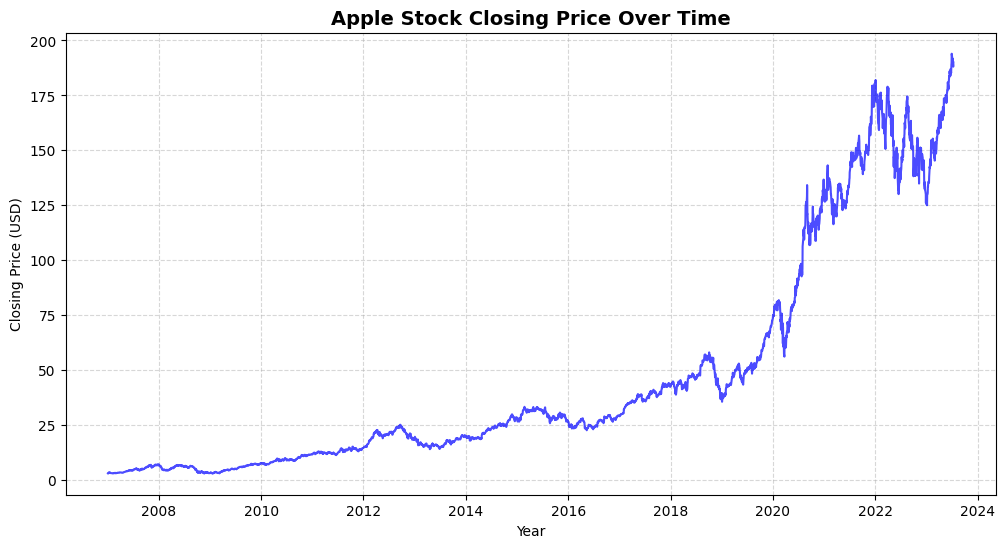

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df_apple.index, df_apple['close'], color='blue', alpha=0.7)
plt.title("Apple Stock Closing Price Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Closing Price (USD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


*Plot traded volume over time*

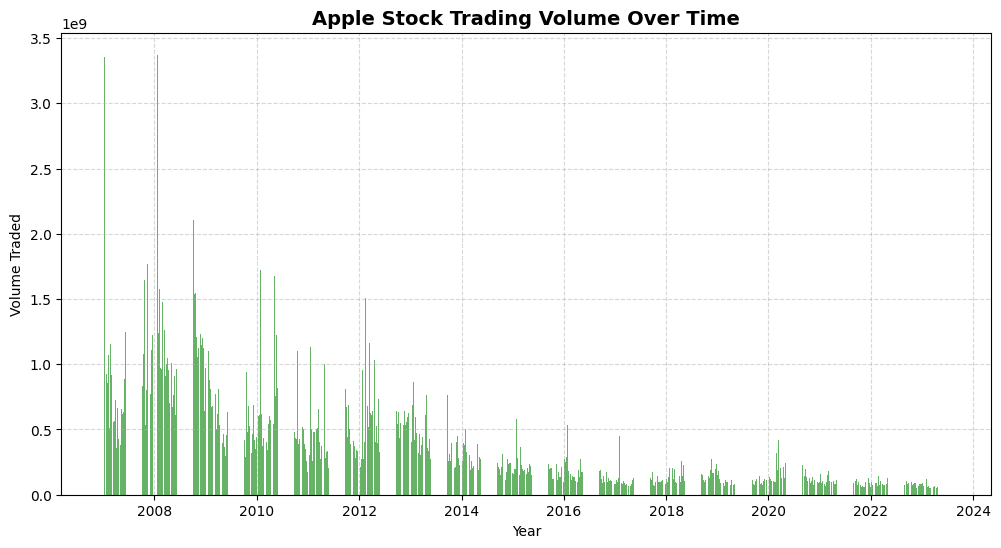

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(df_apple.index, df_apple['volume'], color='green', alpha=0.6)
plt.title("Apple Stock Trading Volume Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Volume Traded")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


- Create a candlestick chart to depict high and low prices.

In [12]:
!pip install mplfinance

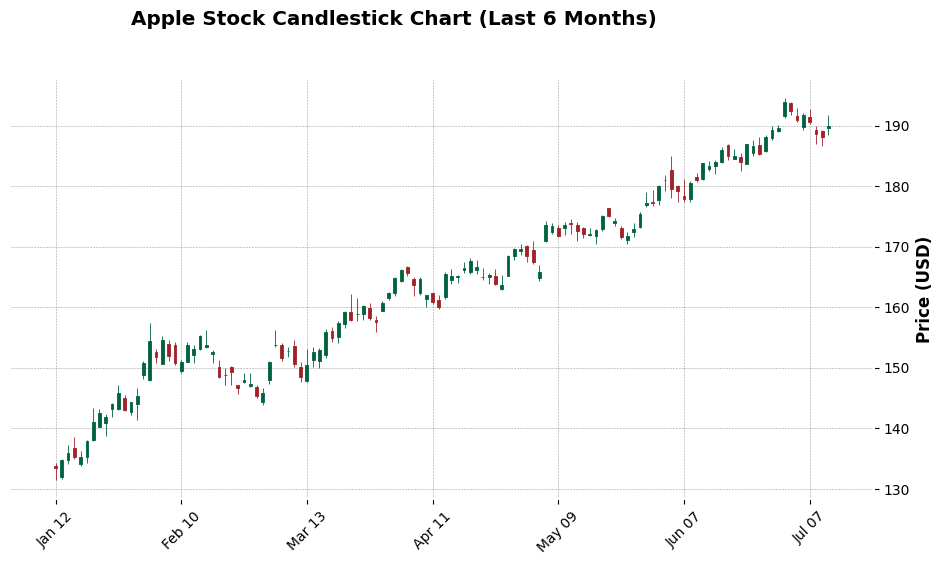

In [13]:
import mplfinance as mpf

# Selecting only the required columns for candlestick chart
# candlestick_data = df_apple[['open', 'high', 'low', 'close']].copy()

# Select the last 6 months of data because it's not possible
# to plot all the data
candlestick_data = df_apple.loc[df_apple.index >= df_apple.index.max() - pd.DateOffset(months=6)]

# Plot candlestick chart
mpf.plot(candlestick_data, type='candle', style='charles', figsize=(12,6),
         title="Apple Stock Candlestick Chart (Last 6 Months)", ylabel="Price (USD)")


**Statistical Analysis**

- Compute summary statistics (mean, median, standard deviation) for key columns.

In [14]:
summary_stats = df_apple[['close', 'volume', 'high', 'low']].agg(['mean', 'median', 'std'])
summary_stats

,close,volume,high,low
mean,46.396058,3.662925e+08,46.881127,45.865790
median,25.825000,2.136463e+08,26.262800,25.680000
std,50.293482,3.724793e+08,50.843874,49.680104


- Analyze closing prices with a moving average.


*A moving average smooths price trends by averaging past values over a time window.*

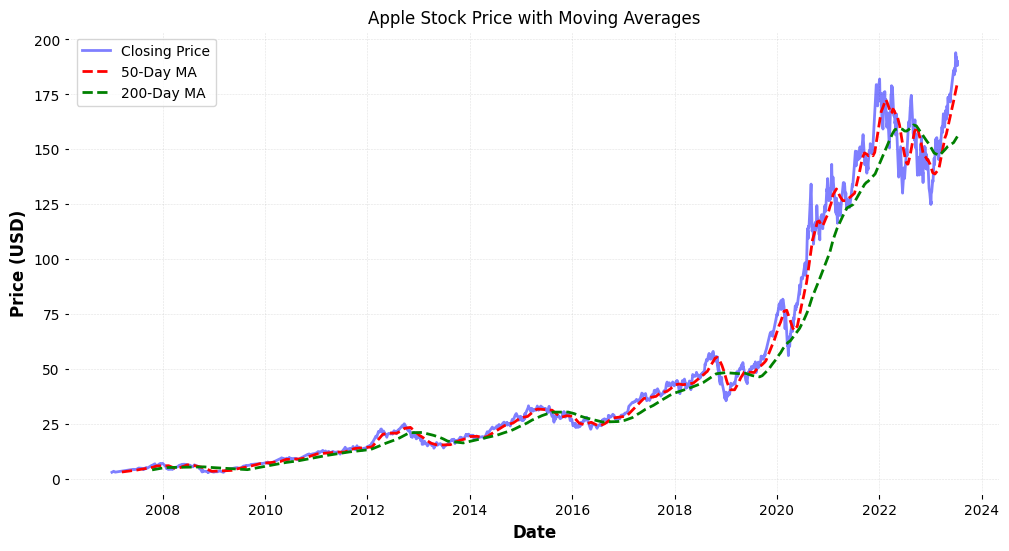

In [15]:
df_apple['MA_50'] = df_apple['close'].rolling(window=50).mean()
df_apple['MA_200'] = df_apple['close'].rolling(window=200).mean()

# Plot closing prices and moving averages
plt.figure(figsize=(12,6))
plt.plot(df_apple.index, df_apple['close'], label="Closing Price", color='blue', alpha=0.5)
plt.plot(df_apple.index, df_apple['MA_50'], label="50-Day MA", color='red', linestyle='--')
plt.plot(df_apple.index, df_apple['MA_200'], label="200-Day MA", color='green', linestyle='--')

plt.title("Apple Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Hypothesis Testing**

- Execute a t-test to compare average closing prices across different years.


In [16]:
# Extract the year from the index
df_apple['Year'] = df_apple.index.year

# Select two years for comparison
year_1 = 2010
year_2 = 2020

# Filter closing prices for the selected years
close_year_1 = df_apple[df_apple['Year'] == year_1]['close']
close_year_2 = df_apple[df_apple['Year'] == year_2]['close']

# Perform an independent t-test
t_stat, p_value = stats.ttest_ind(close_year_1, close_year_2, equal_var=False)

# Interpretation
alpha = 0.05
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

if p_value < alpha:
    print(f"Significant difference in closing prices between {year_1} and {year_2}.")
else:
    print(f"No significant difference in closing prices between {year_1} and {year_2}.")


T-statistic: -62.6499, P-value: 0.0000
Significant difference in closing prices between 2010 and 2020.


- Examine daily returns’ distribution and test for normality using SciPy.

**ct_change()** calculates the percentage change in closing prices from one day to the next.
 - daily return = ((close price at t) - (close price at t-1))/(close price at t-1)

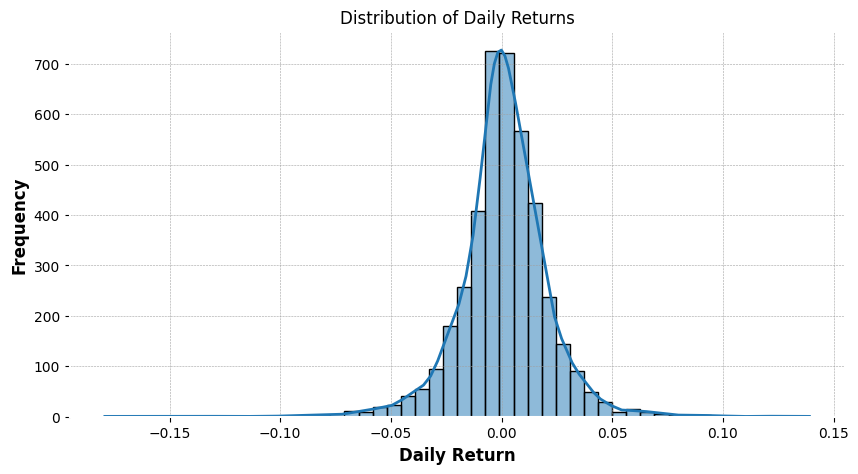

Shapiro-Wilk Test: W = 0.9407, P-value = 0.0000
Kolmogorov-Smirnov Test: D = 0.4691, P-value = 0.0000
Daily returns do NOT follow a normal distribution (Shapiro-Wilk test).
Daily returns do NOT follow a normal distribution (Kolmogorov-Smirnov test).


In [17]:
# Compute daily returns
df_apple['Daily Return'] = df_apple['close'].pct_change().dropna()

# Plot distribution of daily returns
plt.figure(figsize=(10, 5))
sns.histplot(df_apple['Daily Return'].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

# Perform normality tests
shapiro_test = shapiro(df_apple['Daily Return'].dropna())
ks_test = kstest(df_apple['Daily Return'].dropna(), 'norm')

print(f"Shapiro-Wilk Test: W = {shapiro_test.statistic:.4f}, P-value = {shapiro_test.pvalue:.4f}")
print(f"Kolmogorov-Smirnov Test: D = {ks_test.statistic:.4f}, P-value = {ks_test.pvalue:.4f}")

# Interpretation
alpha = 0.05
if shapiro_test.pvalue < alpha:
    print("Daily returns do NOT follow a normal distribution (Shapiro-Wilk test).")
else:
    print("Daily returns follow a normal distribution (Shapiro-Wilk test).")

if ks_test.pvalue < alpha:
    print("Daily returns do NOT follow a normal distribution (Kolmogorov-Smirnov test).")
else:
    print("Daily returns follow a normal distribution (Kolmogorov-Smirnov test).")

**Advanced Statistical Techniques (Bonus)**

- Use convolve for moving averages, or np.corrcoef to explore correlations between financial metrics.

In [18]:
window_size = 20  # 20-day moving average
weights = np.ones(window_size) / window_size

# Compute moving average for closing price
df_apple["Moving_Avg_Close"] = np.convolve(df_apple["close"], weights, mode="same")

# Compute moving average for trading volume
df_apple["Moving_Avg_Volume"] = np.convolve(df_apple["volume"], weights, mode="same")


*np.convolve* efficiently computes rolling averages by applying a moving window to the data.
The weights normalize the sum so that each window has an equal contribution.

In [19]:
correlation_matrix = np.corrcoef(df_apple["Moving_Avg_Close"].dropna(), df_apple["Moving_Avg_Volume"].dropna())

print(f"Correlation between Moving Avg of Close and Volume: {correlation_matrix[0, 1]:.4f}")


Correlation between Moving Avg of Close and Volume: -0.5764


The correlation is **negative**. Price movements may be driven by other factors.

- Analyze correlations between moving averages of closing prices and trading volume across time periods.

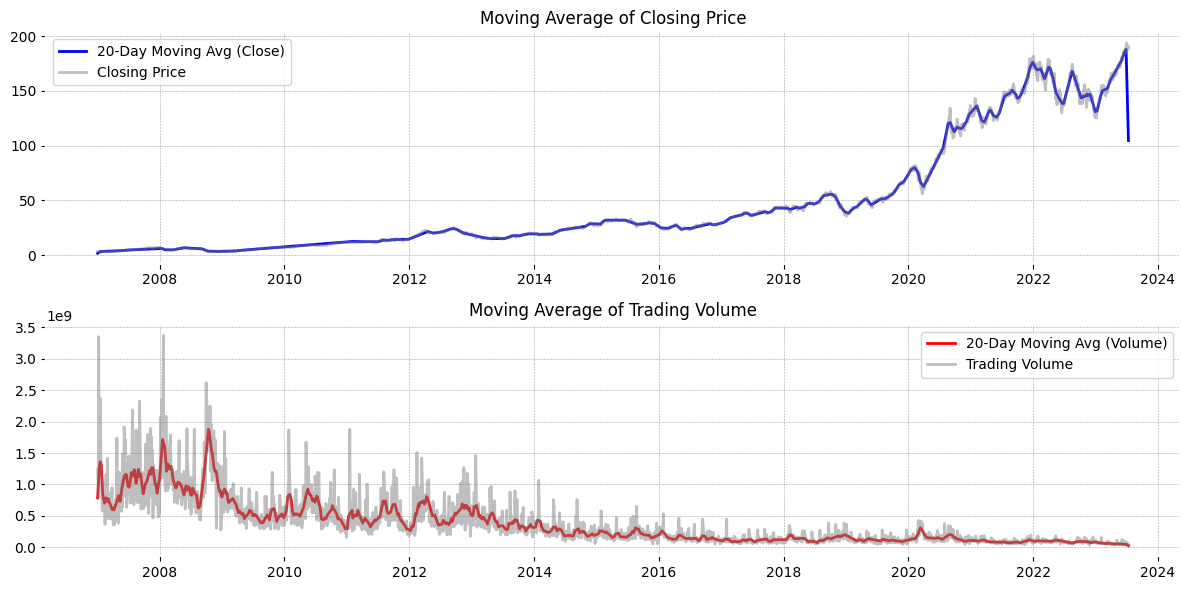

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot Closing Price Moving Average
plt.subplot(2, 1, 1)
plt.plot(df_apple.index, df_apple["Moving_Avg_Close"], label="20-Day Moving Avg (Close)", color="blue")
plt.plot(df_apple.index, df_apple["close"], label="Closing Price", color="gray", alpha=0.5)
plt.legend()
plt.title("Moving Average of Closing Price")

# Plot Volume Moving Average
plt.subplot(2, 1, 2)
plt.plot(df_apple.index, df_apple["Moving_Avg_Volume"], label="20-Day Moving Avg (Volume)", color="red")
plt.plot(df_apple.index, df_apple["volume"], label="Trading Volume", color="gray", alpha=0.5)
plt.legend()
plt.title("Moving Average of Trading Volume")

plt.tight_layout()
plt.show()


**Summary and Insights**

- Apple's stock price has shown strong upward momentum over the years, with periodic fluctuations.
- Trading volume is volatile, possibly due to quarterly reports or macroeconomic events.
- Statistical tests confirm significant differences in stock prices across years, reflecting Apple's growth.
- Daily returns do not follow a normal distribution, meaning price changes are influenced by external factors like market news, investor sentiment, or macroeconomic conditions.
- Moving averages highlight long-term trends and provide useful indicators for market analysis.